---
title: "Gaming Tutor: Can LLMs Help Me Create a Game?"
description: "Learning to code a game as a complete coding novice from LLMs!"
author: "Lindsey Lee"
date: "12/13/2025"
categories:
  - LLMs
  - Fun
  - Creative 
---

---

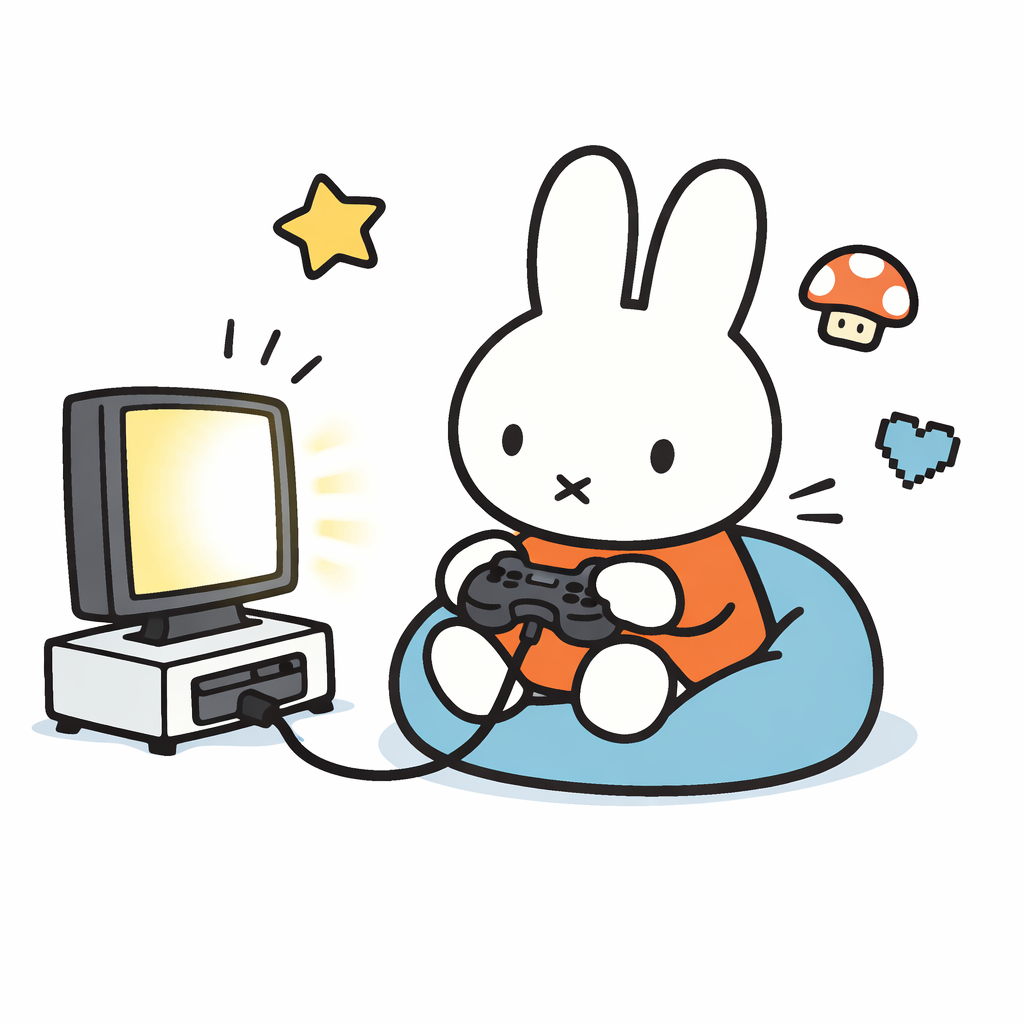

With only one rudimentary python coding class under my belt, it's been a true challenge to realize my hidden dream to be a game developer. However, given the computing and coding ability of LLMs, I was curious to see whether they can create a game from scratch if I gave it some guidelines--and given the restrictions of this managed jupyter notebook.

I heard much about the coding capabilities of Claude-Sonnet 3.5, so I chose this LLM to be my coding buddy to create the classic game, Breakout, with some twists.

My revised game rules are included in the prompt I fed Claude:

> Write me code for a game of Breakout that I can run on jupyter notebook in python. Please note that I am using a managed JupyterHub with no permission to install system packages. I want the following elements to be included:
> - point system as you hit bricks
> - a power up spawns in the form of a special brick that can expand the length of the platform. this power up randomly generates at the first minute (replacing one of the original brick blocks) and every 3 minutes after. The power up is granted upon the ball hitting it.
> - at least 100 bricks
> - 3 lives

---

### First Draft

In [10]:
import time
import random
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from threading import Thread

class BreakoutGame:
    def __init__(self):
        self.width = 800
        self.height = 600
        self.running = False
        
        # Game variables
        self.score = 0
        self.lives = 3
        self.game_over = False
        self.start_time = None
        self.last_powerup_time = None
        self.powerup_active = False
        self.powerup_brick_idx = None
        
        # Paddle
        self.paddle_width = 100
        self.paddle_height = 15
        self.paddle_x = self.width // 2 - self.paddle_width // 2
        self.paddle_y = self.height - 50
        
        # Ball
        self.ball_radius = 8
        self.ball_x = self.width // 2
        self.ball_y = self.height - 70
        self.ball_dx = 4
        self.ball_dy = -4
        
        # Bricks
        self.bricks = []
        self.brick_width = 75
        self.brick_height = 20
        self.brick_colors = ['#FF0000', '#FF7F00', '#FFFF00', '#00FF00', '#0000FF', '#8B00FF']
        self.create_bricks()
        
        # Key states
        self.left_pressed = False
        self.right_pressed = False
        
        self.setup_ui()
    
    def create_bricks(self):
        rows = 10
        cols = 10
        offset_x = (self.width - cols * self.brick_width) // 2
        offset_y = 50
        
        for row in range(rows):
            for col in range(cols):
                x = offset_x + col * self.brick_width
                y = offset_y + row * self.brick_height
                color = self.brick_colors[row % len(self.brick_colors)]
                points = (10 - row) * 10
                self.bricks.append({
                    'x': x, 'y': y, 
                    'color': color, 
                    'points': points,
                    'powerup': False,
                    'active': True
                })
    
    def setup_ui(self):
        self.output = widgets.Output()
        
        # Buttons for controls
        self.left_btn = widgets.Button(description='◄ Left (A)')
        self.right_btn = widgets.Button(description='Right (D) ►')
        self.start_btn = widgets.Button(description='Start Game', button_style='success')
        
        self.left_btn.on_click(lambda b: self.on_left_press())
        self.right_btn.on_click(lambda b: self.on_right_press())
        self.start_btn.on_click(lambda b: self.start_game())
        
        # Keyboard capture
        self.kbd = widgets.HTML(value='<div id="kbd_capture" tabindex="0" style="width:100%;height:50px;border:2px solid #ccc;text-align:center;line-height:50px;cursor:pointer;">Click here, then use A/D keys to move</div>')
        
        controls = widgets.HBox([self.left_btn, self.right_btn, self.start_btn])
        
        display(widgets.VBox([controls, self.kbd, self.output]))
        
        # JavaScript for keyboard
        display(HTML('''
        <script>
        document.addEventListener('keydown', function(e) {
            if(e.key === 'a' || e.key === 'A' || e.key === 'ArrowLeft') {
                window.leftPressed = true;
            }
            if(e.key === 'd' || e.key === 'D' || e.key === 'ArrowRight') {
                window.rightPressed = true;
            }
        });
        document.addEventListener('keyup', function(e) {
            if(e.key === 'a' || e.key === 'A' || e.key === 'ArrowLeft') {
                window.leftPressed = false;
            }
            if(e.key === 'd' || e.key === 'D' || e.key === 'ArrowRight') {
                window.rightPressed = false;
            }
        });
        </script>
        '''))
    
    def on_left_press(self):
        if self.running and not self.game_over:
            self.paddle_x = max(0, self.paddle_x - 30)
    
    def on_right_press(self):
        if self.running and not self.game_over:
            self.paddle_x = min(self.width - self.paddle_width, self.paddle_x + 30)
    
    def spawn_powerup(self):
        active_bricks = [i for i, b in enumerate(self.bricks) if b['active']]
        if active_bricks and not self.powerup_active:
            # Clear old powerup
            if self.powerup_brick_idx is not None:
                self.bricks[self.powerup_brick_idx]['powerup'] = False
            
            # Select random active brick
            idx = random.choice(active_bricks)
            self.bricks[idx]['powerup'] = True
            self.powerup_brick_idx = idx
            self.powerup_active = True
    
    def expand_paddle(self):
        self.paddle_width = min(150, self.paddle_width + 30)
    
    def check_collision(self, bx, by, x1, y1, x2, y2):
        return (bx + self.ball_radius >= x1 and 
                bx - self.ball_radius <= x2 and
                by + self.ball_radius >= y1 and 
                by - self.ball_radius <= y2)
    
    def update_game(self):
        # Check powerup timing
        current_time = time.time()
        elapsed = current_time - self.last_powerup_time
        
        if (elapsed >= 60 and self.last_powerup_time == self.start_time) or \
           (elapsed >= 180 and self.last_powerup_time != self.start_time):
            self.spawn_powerup()
            self.last_powerup_time = current_time
        
        # Move ball
        self.ball_x += self.ball_dx
        self.ball_y += self.ball_dy
        
        # Wall collisions
        if self.ball_x - self.ball_radius <= 0 or self.ball_x + self.ball_radius >= self.width:
            self.ball_dx = -self.ball_dx
        
        if self.ball_y - self.ball_radius <= 0:
            self.ball_dy = -self.ball_dy
        
        # Paddle collision
        if self.check_collision(self.ball_x, self.ball_y, 
                               self.paddle_x, self.paddle_y,
                               self.paddle_x + self.paddle_width, 
                               self.paddle_y + self.paddle_height):
            if self.ball_dy > 0:  # Only if ball is moving down
                self.ball_dy = -abs(self.ball_dy)
                # Angle based on hit position
                hit_pos = (self.ball_x - self.paddle_x) / self.paddle_width
                self.ball_dx = (hit_pos - 0.5) * 8
        
        # Brick collision
        for i, brick in enumerate(self.bricks):
            if brick['active']:
                if self.check_collision(self.ball_x, self.ball_y,
                                       brick['x'], brick['y'],
                                       brick['x'] + self.brick_width,
                                       brick['y'] + self.brick_height):
                    if brick['powerup']:
                        self.expand_paddle()
                        self.powerup_active = False
                        self.powerup_brick_idx = None
                    
                    self.score += brick['points']
                    brick['active'] = False
                    self.ball_dy = -self.ball_dy
                    break
        
        # Ball falls
        if self.ball_y - self.ball_radius > self.height:
            self.lives -= 1
            if self.lives > 0:
                self.ball_x = self.width // 2
                self.ball_y = self.height - 70
                self.ball_dx = 4
                self.ball_dy = -4
                self.paddle_width = 100  # Reset paddle
                self.paddle_x = self.width // 2 - self.paddle_width // 2
            else:
                self.game_over = True
                self.running = False
        
        # Check win
        if all(not b['active'] for b in self.bricks):
            self.game_over = True
            self.running = False
    
    def draw(self):
        svg = f'''
        <svg width="{self.width}" height="{self.height}" style="border:2px solid #333; background:#000;">
        '''
        
        # Draw bricks
        for brick in self.bricks:
            if brick['active']:
                color = '#FFD700' if brick['powerup'] else brick['color']
                svg += f'<rect x="{brick["x"]+2}" y="{brick["y"]+2}" width="{self.brick_width-4}" height="{self.brick_height-4}" fill="{color}" stroke="#000" stroke-width="1"/>'
        
        # Draw paddle
        svg += f'<rect x="{self.paddle_x}" y="{self.paddle_y}" width="{self.paddle_width}" height="{self.paddle_height}" fill="#FFF"/>'
        
        # Draw ball
        svg += f'<circle cx="{self.ball_x}" cy="{self.ball_y}" r="{self.ball_radius}" fill="#FFF"/>'
        
        # Draw score
        svg += f'<text x="10" y="25" fill="#FFF" font-size="18" font-family="Arial">Score: {self.score}  Lives: {self.lives}</text>'
        
        # Game over message
        if self.game_over:
            msg = "YOU WIN!" if all(not b['active'] for b in self.bricks) else "GAME OVER!"
            svg += f'<text x="{self.width//2}" y="{self.height//2}" fill="#FFF" font-size="48" font-family="Arial" text-anchor="middle">{msg}</text>'
            svg += f'<text x="{self.width//2}" y="{self.height//2 + 50}" fill="#FFF" font-size="24" font-family="Arial" text-anchor="middle">Final Score: {self.score}</text>'
        
        svg += '</svg>'
        return svg
    
    def game_loop(self):
        while self.running:
            self.update_game()
            
            with self.output:
                clear_output(wait=True)
                display(HTML(self.draw()))
            
            time.sleep(0.03)  # ~30 FPS
        
        # Final draw
        with self.output:
            clear_output(wait=True)
            display(HTML(self.draw()))
    
    def start_game(self):
        if not self.running:
            self.running = True
            self.start_time = time.time()
            self.last_powerup_time = self.start_time
            self.start_btn.description = 'Game Running...'
            self.start_btn.button_style = 'info'
            thread = Thread(target=self.game_loop)
            thread.daemon = True
            thread.start()

# Create and display the game
game = BreakoutGame()
print("Game loaded! Click 'Start Game' to begin. Use the buttons or A/D keys to move the paddle.")

Game loaded! Click 'Start Game' to begin. Use the buttons or A/D keys to move the paddle.


---

In this first draft, upon selecting the game to start, the game remain stuck on "game running" without allowing the player to actually play the game. I screen shotted the loading screen and asked Claude to address the issue.

---

### Second Draft

In [12]:
import time
import random
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

class BreakoutGame:
    def __init__(self):
        self.width = 800
        self.height = 600
        
        # Game variables
        self.score = 0
        self.lives = 3
        self.game_over = False
        self.game_started = False
        self.start_time = None
        self.last_powerup_time = None
        self.powerup_active = False
        self.powerup_brick_idx = None
        
        # Paddle
        self.paddle_width = 100
        self.paddle_height = 15
        self.paddle_x = self.width // 2 - self.paddle_width // 2
        self.paddle_y = self.height - 50
        
        # Ball
        self.ball_radius = 8
        self.ball_x = self.width // 2
        self.ball_y = self.height - 70
        self.ball_dx = 4
        self.ball_dy = -4
        
        # Bricks
        self.bricks = []
        self.brick_width = 75
        self.brick_height = 20
        self.brick_colors = ['#FF0000', '#FF7F00', '#FFFF00', '#00FF00', '#0000FF', '#8B00FF']
        self.create_bricks()
        
        self.setup_ui()
    
    def create_bricks(self):
        rows = 10
        cols = 10
        offset_x = (self.width - cols * self.brick_width) // 2
        offset_y = 50
        
        for row in range(rows):
            for col in range(cols):
                x = offset_x + col * self.brick_width
                y = offset_y + row * self.brick_height
                color = self.brick_colors[row % len(self.brick_colors)]
                points = (10 - row) * 10
                self.bricks.append({
                    'x': x, 'y': y, 
                    'color': color, 
                    'points': points,
                    'powerup': False,
                    'active': True
                })
    
    def setup_ui(self):
        # Buttons for controls
        self.left_btn = widgets.Button(description='◄ Left (A)', layout=widgets.Layout(width='150px'))
        self.right_btn = widgets.Button(description='Right (D) ►', layout=widgets.Layout(width='150px'))
        self.start_btn = widgets.Button(description='Start Game', button_style='success', layout=widgets.Layout(width='150px'))
        
        self.left_btn.on_click(lambda b: self.on_left_press())
        self.right_btn.on_click(lambda b: self.on_right_press())
        self.start_btn.on_click(lambda b: self.start_game())
        
        controls = widgets.HBox([self.left_btn, self.right_btn, self.start_btn])
        
        # Canvas output
        self.canvas = widgets.HTML(value=self.draw())
        
        display(widgets.VBox([controls, self.canvas]))
        
        print("Game loaded! Click 'Start Game' to begin. Use the buttons to move the paddle.")
    
    def on_left_press(self):
        if self.game_started and not self.game_over:
            self.paddle_x = max(0, self.paddle_x - 40)
    
    def on_right_press(self):
        if self.game_started and not self.game_over:
            self.paddle_x = min(self.width - self.paddle_width, self.paddle_x + 40)
    
    def spawn_powerup(self):
        active_bricks = [i for i, b in enumerate(self.bricks) if b['active']]
        if active_bricks and not self.powerup_active:
            # Clear old powerup
            if self.powerup_brick_idx is not None:
                self.bricks[self.powerup_brick_idx]['powerup'] = False
            
            # Select random active brick
            idx = random.choice(active_bricks)
            self.bricks[idx]['powerup'] = True
            self.powerup_brick_idx = idx
            self.powerup_active = True
    
    def expand_paddle(self):
        self.paddle_width = min(150, self.paddle_width + 30)
    
    def check_collision(self, bx, by, x1, y1, x2, y2):
        return (bx + self.ball_radius >= x1 and 
                bx - self.ball_radius <= x2 and
                by + self.ball_radius >= y1 and 
                by - self.ball_radius <= y2)
    
    def update_game(self):
        if not self.game_started or self.game_over:
            return
        
        # Check powerup timing
        current_time = time.time()
        elapsed = current_time - self.last_powerup_time
        
        if (elapsed >= 60 and self.last_powerup_time == self.start_time) or \
           (elapsed >= 180 and self.last_powerup_time != self.start_time):
            self.spawn_powerup()
            self.last_powerup_time = current_time
        
        # Move ball
        self.ball_x += self.ball_dx
        self.ball_y += self.ball_dy
        
        # Wall collisions
        if self.ball_x - self.ball_radius <= 0 or self.ball_x + self.ball_radius >= self.width:
            self.ball_dx = -self.ball_dx
        
        if self.ball_y - self.ball_radius <= 0:
            self.ball_dy = -self.ball_dy
        
        # Paddle collision
        if self.check_collision(self.ball_x, self.ball_y, 
                               self.paddle_x, self.paddle_y,
                               self.paddle_x + self.paddle_width, 
                               self.paddle_y + self.paddle_height):
            if self.ball_dy > 0:  # Only if ball is moving down
                self.ball_dy = -abs(self.ball_dy)
                # Angle based on hit position
                hit_pos = (self.ball_x - self.paddle_x) / self.paddle_width
                self.ball_dx = (hit_pos - 0.5) * 8
        
        # Brick collision
        for i, brick in enumerate(self.bricks):
            if brick['active']:
                if self.check_collision(self.ball_x, self.ball_y,
                                       brick['x'], brick['y'],
                                       brick['x'] + self.brick_width,
                                       brick['y'] + self.brick_height):
                    if brick['powerup']:
                        self.expand_paddle()
                        self.powerup_active = False
                        self.powerup_brick_idx = None
                    
                    self.score += brick['points']
                    brick['active'] = False
                    self.ball_dy = -self.ball_dy
                    break
        
        # Ball falls
        if self.ball_y - self.ball_radius > self.height:
            self.lives -= 1
            if self.lives > 0:
                self.ball_x = self.width // 2
                self.ball_y = self.height - 70
                self.ball_dx = 4
                self.ball_dy = -4
                self.paddle_width = 100  # Reset paddle
                self.paddle_x = self.width // 2 - self.paddle_width // 2
            else:
                self.game_over = True
        
        # Check win
        if all(not b['active'] for b in self.bricks):
            self.game_over = True
        
        # Update display
        self.canvas.value = self.draw()
    
    def draw(self):
        svg = f'<svg width="{self.width}" height="{self.height}" style="border:2px solid #333; background:#000;">'
        
        # Draw bricks
        for brick in self.bricks:
            if brick['active']:
                color = '#FFD700' if brick['powerup'] else brick['color']
                svg += f'<rect x="{brick["x"]+2}" y="{brick["y"]+2}" width="{self.brick_width-4}" height="{self.brick_height-4}" fill="{color}" stroke="#000" stroke-width="1"/>'
        
        # Draw paddle
        svg += f'<rect x="{self.paddle_x}" y="{self.paddle_y}" width="{self.paddle_width}" height="{self.paddle_height}" fill="#FFF"/>'
        
        # Draw ball
        svg += f'<circle cx="{self.ball_x}" cy="{self.ball_y}" r="{self.ball_radius}" fill="#FFF"/>'
        
        # Draw score
        svg += f'<text x="10" y="25" fill="#FFF" font-size="18" font-family="Arial">Score: {self.score}  Lives: {self.lives}</text>'
        
        # Game over message
        if self.game_over:
            msg = "YOU WIN!" if all(not b['active'] for b in self.bricks) else "GAME OVER!"
            svg += f'<text x="{self.width//2}" y="{self.height//2}" fill="#FFF" font-size="48" font-family="Arial" text-anchor="middle">{msg}</text>'
            svg += f'<text x="{self.width//2}" y="{self.height//2 + 50}" fill="#FFF" font-size="24" font-family="Arial" text-anchor="middle">Final Score: {self.score}</text>'
        
        svg += '</svg>'
        return svg
    
    def game_loop(self):
        while self.game_started and not self.game_over:
            self.update_game()
            time.sleep(0.033)  # ~30 FPS
        
        # Final update when game ends
        if self.game_over:
            self.canvas.value = self.draw()
    
    def start_game(self):
        if not self.game_started:
            self.game_started = True
            self.start_time = time.time()
            self.last_powerup_time = self.start_time
            self.start_btn.description = 'Playing...'
            self.start_btn.button_style = 'info'
            self.start_btn.disabled = True
            
            # Start game loop in background
            import threading
            thread = threading.Thread(target=self.game_loop)
            thread.daemon = True
            thread.start()

# Create and run the game
game = BreakoutGame()

Game loaded! Click 'Start Game' to begin. Use the buttons to move the paddle.


---

This time, the game was able to load successfully, and in addition to working exactly as imagined, it looks great too! Despite this, I wanted to add a couple of improvements to the game, so I asked Claude to incorporate the following features:

- stopwatch showing how long it has been since the game started
- indicate the powerup brick with a star on the brick
- increase the speed of the ball after every brick it breaks by 0.02%

---

### Third Draft

In [13]:
import time
import random
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

class BreakoutGame:
    def __init__(self):
        self.width = 800
        self.height = 600
        
        # Game variables
        self.score = 0
        self.lives = 3
        self.game_over = False
        self.game_started = False
        self.start_time = None
        self.last_powerup_time = None
        self.powerup_active = False
        self.powerup_brick_idx = None
        
        # Paddle
        self.paddle_width = 100
        self.paddle_height = 15
        self.paddle_x = self.width // 2 - self.paddle_width // 2
        self.paddle_y = self.height - 50
        
        # Ball
        self.ball_radius = 8
        self.ball_x = self.width // 2
        self.ball_y = self.height - 70
        self.ball_dx = 4
        self.ball_dy = -4
        
        # Bricks
        self.bricks = []
        self.brick_width = 75
        self.brick_height = 20
        self.brick_colors = ['#FF0000', '#FF7F00', '#FFFF00', '#00FF00', '#0000FF', '#8B00FF']
        self.create_bricks()
        
        self.setup_ui()
    
    def create_bricks(self):
        rows = 10
        cols = 10
        offset_x = (self.width - cols * self.brick_width) // 2
        offset_y = 50
        
        for row in range(rows):
            for col in range(cols):
                x = offset_x + col * self.brick_width
                y = offset_y + row * self.brick_height
                color = self.brick_colors[row % len(self.brick_colors)]
                points = (10 - row) * 10
                self.bricks.append({
                    'x': x, 'y': y, 
                    'color': color, 
                    'points': points,
                    'powerup': False,
                    'active': True
                })
    
    def setup_ui(self):
        # Buttons for controls
        self.left_btn = widgets.Button(description='◄ Left (A)', layout=widgets.Layout(width='150px'))
        self.right_btn = widgets.Button(description='Right (D) ►', layout=widgets.Layout(width='150px'))
        self.start_btn = widgets.Button(description='Start Game', button_style='success', layout=widgets.Layout(width='150px'))
        
        self.left_btn.on_click(lambda b: self.on_left_press())
        self.right_btn.on_click(lambda b: self.on_right_press())
        self.start_btn.on_click(lambda b: self.start_game())
        
        controls = widgets.HBox([self.left_btn, self.right_btn, self.start_btn])
        
        # Canvas output
        self.canvas = widgets.HTML(value=self.draw())
        
        display(widgets.VBox([controls, self.canvas]))
        
        print("Game loaded! Click 'Start Game' to begin. Use the buttons to move the paddle.")
    
    def on_left_press(self):
        if self.game_started and not self.game_over:
            self.paddle_x = max(0, self.paddle_x - 40)
    
    def on_right_press(self):
        if self.game_started and not self.game_over:
            self.paddle_x = min(self.width - self.paddle_width, self.paddle_x + 40)
    
    def spawn_powerup(self):
        active_bricks = [i for i, b in enumerate(self.bricks) if b['active']]
        if active_bricks and not self.powerup_active:
            # Clear old powerup
            if self.powerup_brick_idx is not None:
                self.bricks[self.powerup_brick_idx]['powerup'] = False
            
            # Select random active brick
            idx = random.choice(active_bricks)
            self.bricks[idx]['powerup'] = True
            self.powerup_brick_idx = idx
            self.powerup_active = True
    
    def expand_paddle(self):
        self.paddle_width = min(150, self.paddle_width + 30)
    
    def check_collision(self, bx, by, x1, y1, x2, y2):
        return (bx + self.ball_radius >= x1 and 
                bx - self.ball_radius <= x2 and
                by + self.ball_radius >= y1 and 
                by - self.ball_radius <= y2)
    
    def update_game(self):
        if not self.game_started or self.game_over:
            return
        
        # Check powerup timing
        current_time = time.time()
        elapsed = current_time - self.last_powerup_time
        
        if (elapsed >= 60 and self.last_powerup_time == self.start_time) or \
           (elapsed >= 180 and self.last_powerup_time != self.start_time):
            self.spawn_powerup()
            self.last_powerup_time = current_time
        
        # Move ball
        self.ball_x += self.ball_dx
        self.ball_y += self.ball_dy
        
        # Wall collisions
        if self.ball_x - self.ball_radius <= 0 or self.ball_x + self.ball_radius >= self.width:
            self.ball_dx = -self.ball_dx
        
        if self.ball_y - self.ball_radius <= 0:
            self.ball_dy = -self.ball_dy
        
        # Paddle collision
        if self.check_collision(self.ball_x, self.ball_y, 
                               self.paddle_x, self.paddle_y,
                               self.paddle_x + self.paddle_width, 
                               self.paddle_y + self.paddle_height):
            if self.ball_dy > 0:  # Only if ball is moving down
                self.ball_dy = -abs(self.ball_dy)
                # Angle based on hit position
                hit_pos = (self.ball_x - self.paddle_x) / self.paddle_width
                self.ball_dx = (hit_pos - 0.5) * 8
        
        # Brick collision
        for i, brick in enumerate(self.bricks):
            if brick['active']:
                if self.check_collision(self.ball_x, self.ball_y,
                                       brick['x'], brick['y'],
                                       brick['x'] + self.brick_width,
                                       brick['y'] + self.brick_height):
                    if brick['powerup']:
                        self.expand_paddle()
                        self.powerup_active = False
                        self.powerup_brick_idx = None
                    
                    self.score += brick['points']
                    brick['active'] = False
                    self.ball_dy = -self.ball_dy
                    
                    # Increase ball speed by 0.02%
                    speed_multiplier = 1.0002
                    self.ball_dx *= speed_multiplier
                    self.ball_dy *= speed_multiplier
                    break
        
        # Ball falls
        if self.ball_y - self.ball_radius > self.height:
            self.lives -= 1
            if self.lives > 0:
                self.ball_x = self.width // 2
                self.ball_y = self.height - 70
                self.ball_dx = 4
                self.ball_dy = -4
                self.paddle_width = 100  # Reset paddle
                self.paddle_x = self.width // 2 - self.paddle_width // 2
            else:
                self.game_over = True
        
        # Check win
        if all(not b['active'] for b in self.bricks):
            self.game_over = True
        
        # Update display
        self.canvas.value = self.draw()
    
    def draw(self):
        svg = f'<svg width="{self.width}" height="{self.height}" style="border:2px solid #333; background:#000;">'
        
        # Draw bricks
        for brick in self.bricks:
            if brick['active']:
                color = '#FFD700' if brick['powerup'] else brick['color']
                svg += f'<rect x="{brick["x"]+2}" y="{brick["y"]+2}" width="{self.brick_width-4}" height="{self.brick_height-4}" fill="{color}" stroke="#000" stroke-width="1"/>'
                
                # Draw star on powerup brick
                if brick['powerup']:
                    cx = brick['x'] + self.brick_width // 2
                    cy = brick['y'] + self.brick_height // 2
                    svg += f'<text x="{cx}" y="{cy+5}" fill="#000" font-size="16" font-family="Arial" text-anchor="middle">★</text>'
        
        # Draw paddle
        svg += f'<rect x="{self.paddle_x}" y="{self.paddle_y}" width="{self.paddle_width}" height="{self.paddle_height}" fill="#FFF"/>'
        
        # Draw ball
        svg += f'<circle cx="{self.ball_x}" cy="{self.ball_y}" r="{self.ball_radius}" fill="#FFF"/>'
        
        # Draw score and timer
        elapsed_time = 0
        if self.game_started and self.start_time:
            elapsed_time = int(time.time() - self.start_time)
        minutes = elapsed_time // 60
        seconds = elapsed_time % 60
        svg += f'<text x="10" y="25" fill="#FFF" font-size="18" font-family="Arial">Score: {self.score}  Lives: {self.lives}  Time: {minutes:02d}:{seconds:02d}</text>'
        
        # Game over message
        if self.game_over:
            msg = "YOU WIN!" if all(not b['active'] for b in self.bricks) else "GAME OVER!"
            svg += f'<text x="{self.width//2}" y="{self.height//2}" fill="#FFF" font-size="48" font-family="Arial" text-anchor="middle">{msg}</text>'
            svg += f'<text x="{self.width//2}" y="{self.height//2 + 50}" fill="#FFF" font-size="24" font-family="Arial" text-anchor="middle">Final Score: {self.score}</text>'
        
        svg += '</svg>'
        return svg
    
    def game_loop(self):
        while self.game_started and not self.game_over:
            self.update_game()
            time.sleep(0.033)  # ~30 FPS
        
        # Final update when game ends
        if self.game_over:
            self.canvas.value = self.draw()
    
    def start_game(self):
        if not self.game_started:
            self.game_started = True
            self.start_time = time.time()
            self.last_powerup_time = self.start_time
            self.start_btn.description = 'Playing...'
            self.start_btn.button_style = 'info'
            self.start_btn.disabled = True
            
            # Start game loop in background
            import threading
            thread = threading.Thread(target=self.game_loop)
            thread.daemon = True
            thread.start()

# Create and run the game
game = BreakoutGame()

Game loaded! Click 'Start Game' to begin. Use the buttons to move the paddle.


---

The game is improving at great lengths with the help of Claude here! However, I am still left a little unsatisfied with the speed increase percentage. So, I asked Claude for its input, and Claude shared:

> 2% is great if you want an exciting, high-difficulty challenge
>
> 0.5-1% would be better if you want a more gradual, manageable difficulty curve
>
> 0.02% (the original) was way too subtle to notice

With Claude's suggestion and other disatisfactions I had, I wanted propose the following changes:
- Give user two difficulty modes that they can select from before starting the game: Normal (1% speed change) and Hard (2% speed change)
- Place the powerups within 4 brick levels closest to the platform (with consideration of what bricks have been broken)

---

### Fourth Draft

In [17]:
import time
import random
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

class BreakoutGame:
    def __init__(self):
        self.width = 800
        self.height = 600
        
        # Game variables
        self.score = 0
        self.lives = 3
        self.game_over = False
        self.game_started = False
        self.difficulty = 'normal'  # Default difficulty
        self.speed_multiplier = 1.01  # Will be set based on difficulty
        self.start_time = None
        self.last_powerup_time = None
        self.powerup_active = False
        self.powerup_brick_idx = None
        
        # Paddle
        self.paddle_width = 100
        self.paddle_height = 15
        self.paddle_x = self.width // 2 - self.paddle_width // 2
        self.paddle_y = self.height - 50
        
        # Ball
        self.ball_radius = 8
        self.ball_x = self.width // 2
        self.ball_y = self.height - 70
        self.ball_dx = 4
        self.ball_dy = -4
        
        # Bricks
        self.bricks = []
        self.brick_width = 75
        self.brick_height = 20
        self.brick_colors = ['#FF0000', '#FF7F00', '#FFFF00', '#00FF00', '#0000FF', '#8B00FF']
        self.create_bricks()
        
        self.setup_ui()
    
    def create_bricks(self):
        rows = 10
        cols = 10
        offset_x = (self.width - cols * self.brick_width) // 2
        offset_y = 50
        
        for row in range(rows):
            for col in range(cols):
                x = offset_x + col * self.brick_width
                y = offset_y + row * self.brick_height
                color = self.brick_colors[row % len(self.brick_colors)]
                points = (10 - row) * 10
                self.bricks.append({
                    'x': x, 'y': y, 
                    'color': color, 
                    'points': points,
                    'powerup': False,
                    'active': True
                })
    
    def setup_ui(self):
        # Difficulty selection with label
        difficulty_label = widgets.HTML(value='<h3 style="margin:0;">Select Difficulty:</h3>')
        self.difficulty_dropdown = widgets.Dropdown(
            options=[('Normal (1% speed increase)', 'normal'), ('Hard (2% speed increase)', 'hard')],
            value='normal',
            description='',
            layout=widgets.Layout(width='250px')
        )
        
        # Buttons for controls
        self.left_btn = widgets.Button(description='◄ Left (A)', layout=widgets.Layout(width='150px'))
        self.right_btn = widgets.Button(description='Right (D) ►', layout=widgets.Layout(width='150px'))
        self.start_btn = widgets.Button(description='Start Game', button_style='success', layout=widgets.Layout(width='150px'))
        
        self.left_btn.on_click(lambda b: self.on_left_press())
        self.right_btn.on_click(lambda b: self.on_right_press())
        self.start_btn.on_click(lambda b: self.start_game())
        
        controls = widgets.HBox([self.left_btn, self.right_btn, self.start_btn])
        difficulty_box = widgets.VBox([difficulty_label, self.difficulty_dropdown])
        
        # Canvas output
        self.canvas = widgets.HTML(value=self.draw())
        
        display(widgets.VBox([difficulty_box, controls, self.canvas]))
        
        print("Game loaded! Select difficulty and click 'Start Game' to begin. Use the buttons to move the paddle.")
    
    def on_left_press(self):
        if self.game_started and not self.game_over:
            self.paddle_x = max(0, self.paddle_x - 40)
    
    def on_right_press(self):
        if self.game_started and not self.game_over:
            self.paddle_x = min(self.width - self.paddle_width, self.paddle_x + 40)
    
    def spawn_powerup(self):
        # Get bricks in bottom 4 rows that are still active
        bottom_rows_bricks = []
        for i, brick in enumerate(self.bricks):
            if brick['active']:
                # Calculate which row this brick is in (0-9, where 9 is bottom)
                row = int((brick['y'] - 50) / self.brick_height)
                # Only consider bricks in rows 6-9 (bottom 4 rows)
                if row >= 6:
                    bottom_rows_bricks.append(i)
        
        if bottom_rows_bricks and not self.powerup_active:
            # Clear old powerup
            if self.powerup_brick_idx is not None:
                self.bricks[self.powerup_brick_idx]['powerup'] = False
            
            # Select random brick from bottom 4 rows
            idx = random.choice(bottom_rows_bricks)
            self.bricks[idx]['powerup'] = True
            self.powerup_brick_idx = idx
            self.powerup_active = True
    
    def expand_paddle(self):
        self.paddle_width = min(150, self.paddle_width + 30)
    
    def check_collision(self, bx, by, x1, y1, x2, y2):
        return (bx + self.ball_radius >= x1 and 
                bx - self.ball_radius <= x2 and
                by + self.ball_radius >= y1 and 
                by - self.ball_radius <= y2)
    
    def update_game(self):
        if not self.game_started or self.game_over:
            return
        
        # Check powerup timing
        current_time = time.time()
        elapsed = current_time - self.last_powerup_time
        
        if (elapsed >= 60 and self.last_powerup_time == self.start_time) or \
           (elapsed >= 180 and self.last_powerup_time != self.start_time):
            self.spawn_powerup()
            self.last_powerup_time = current_time
        
        # Move ball
        self.ball_x += self.ball_dx
        self.ball_y += self.ball_dy
        
        # Wall collisions
        if self.ball_x - self.ball_radius <= 0 or self.ball_x + self.ball_radius >= self.width:
            self.ball_dx = -self.ball_dx
        
        if self.ball_y - self.ball_radius <= 0:
            self.ball_dy = -self.ball_dy
        
        # Paddle collision
        if self.check_collision(self.ball_x, self.ball_y, 
                               self.paddle_x, self.paddle_y,
                               self.paddle_x + self.paddle_width, 
                               self.paddle_y + self.paddle_height):
            if self.ball_dy > 0:  # Only if ball is moving down
                self.ball_dy = -abs(self.ball_dy)
                # Angle based on hit position
                hit_pos = (self.ball_x - self.paddle_x) / self.paddle_width
                self.ball_dx = (hit_pos - 0.5) * 8
        
        # Brick collision
        for i, brick in enumerate(self.bricks):
            if brick['active']:
                if self.check_collision(self.ball_x, self.ball_y,
                                       brick['x'], brick['y'],
                                       brick['x'] + self.brick_width,
                                       brick['y'] + self.brick_height):
                    if brick['powerup']:
                        self.expand_paddle()
                        self.powerup_active = False
                        self.powerup_brick_idx = None
                    
                    self.score += brick['points']
                    brick['active'] = False
                    self.ball_dy = -self.ball_dy
                    
                    # Increase ball speed based on difficulty
                    self.ball_dx *= self.speed_multiplier
                    self.ball_dy *= self.speed_multiplier
                    break
        
        # Ball falls
        if self.ball_y - self.ball_radius > self.height:
            self.lives -= 1
            if self.lives > 0:
                self.ball_x = self.width // 2
                self.ball_y = self.height - 70
                self.ball_dx = 4
                self.ball_dy = -4
                self.paddle_width = 100  # Reset paddle
                self.paddle_x = self.width // 2 - self.paddle_width // 2
            else:
                self.game_over = True
        
        # Check win
        if all(not b['active'] for b in self.bricks):
            self.game_over = True
        
        # Update display
        self.canvas.value = self.draw()
    
    def draw(self):
        svg = f'<svg width="{self.width}" height="{self.height}" style="border:2px solid #333; background:#000;">'
        
        # Draw bricks
        for brick in self.bricks:
            if brick['active']:
                color = '#FFD700' if brick['powerup'] else brick['color']
                svg += f'<rect x="{brick["x"]+2}" y="{brick["y"]+2}" width="{self.brick_width-4}" height="{self.brick_height-4}" fill="{color}" stroke="#000" stroke-width="1"/>'
                
                # Draw star on powerup brick
                if brick['powerup']:
                    cx = brick['x'] + self.brick_width // 2
                    cy = brick['y'] + self.brick_height // 2
                    svg += f'<text x="{cx}" y="{cy+5}" fill="#000" font-size="16" font-family="Arial" text-anchor="middle">★</text>'
        
        # Draw paddle
        svg += f'<rect x="{self.paddle_x}" y="{self.paddle_y}" width="{self.paddle_width}" height="{self.paddle_height}" fill="#FFF"/>'
        
        # Draw ball
        svg += f'<circle cx="{self.ball_x}" cy="{self.ball_y}" r="{self.ball_radius}" fill="#FFF"/>'
        
        # Draw score and timer
        elapsed_time = 0
        if self.game_started and self.start_time:
            elapsed_time = int(time.time() - self.start_time)
        minutes = elapsed_time // 60
        seconds = elapsed_time % 60
        svg += f'<text x="10" y="25" fill="#FFF" font-size="18" font-family="Arial">Score: {self.score}  Lives: {self.lives}  Time: {minutes:02d}:{seconds:02d}</text>'
        
        # Game over message
        if self.game_over:
            msg = "YOU WIN!" if all(not b['active'] for b in self.bricks) else "GAME OVER!"
            svg += f'<text x="{self.width//2}" y="{self.height//2}" fill="#FFF" font-size="48" font-family="Arial" text-anchor="middle">{msg}</text>'
            svg += f'<text x="{self.width//2}" y="{self.height//2 + 50}" fill="#FFF" font-size="24" font-family="Arial" text-anchor="middle">Final Score: {self.score}</text>'
        
        svg += '</svg>'
        return svg
    
    def game_loop(self):
        while self.game_started and not self.game_over:
            self.update_game()
            time.sleep(0.033)  # ~30 FPS
        
        # Final update when game ends
        if self.game_over:
            self.canvas.value = self.draw()
    
    def start_game(self):
        if not self.game_started:
            # Set difficulty
            self.difficulty = self.difficulty_dropdown.value
            self.speed_multiplier = 1.01 if self.difficulty == 'normal' else 1.02
            
            self.game_started = True
            self.start_time = time.time()
            self.last_powerup_time = self.start_time
            self.start_btn.description = 'Playing...'
            self.start_btn.button_style = 'info'
            self.start_btn.disabled = True
            self.difficulty_dropdown.disabled = True
            
            # Start game loop in background
            import threading
            thread = threading.Thread(target=self.game_loop)
            thread.daemon = True
            thread.start()

# Create and run the game
game = BreakoutGame()

Game loaded! Select difficulty and click 'Start Game' to begin. Use the buttons to move the paddle.


---

This game is now very close to its final product! Now, the last thing I hope to implement in this game is increased point allocation for the hard difficulty mode.

---

### Final Draft

In [25]:
import time
import random
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

class BreakoutGame:
    def __init__(self):
        self.width = 800
        self.height = 600
        
        # Game variables
        self.score = 0
        self.lives = 3
        self.game_over = False
        self.game_started = False
        self.difficulty = 'normal'  # Default difficulty
        self.speed_multiplier = 1.01  # Will be set based on difficulty
        self.start_time = None
        self.last_powerup_time = None
        self.powerup_active = False
        self.powerup_brick_idx = None
        
        # Paddle
        self.paddle_width = 100
        self.paddle_height = 15
        self.paddle_x = self.width // 2 - self.paddle_width // 2
        self.paddle_y = self.height - 50
        
        # Ball
        self.ball_radius = 8
        self.ball_x = self.width // 2
        self.ball_y = self.height - 70
        self.ball_dx = 4
        self.ball_dy = -4
        
        # Bricks
        self.bricks = []
        self.brick_width = 75
        self.brick_height = 20
        self.brick_colors = ['#FF0000', '#FF7F00', '#FFFF00', '#00FF00', '#0000FF', '#8B00FF']
        self.create_bricks()
        
        self.setup_ui()
    
    def create_bricks(self):
        rows = 10
        cols = 10
        offset_x = (self.width - cols * self.brick_width) // 2
        offset_y = 50
        
        for row in range(rows):
            for col in range(cols):
                x = offset_x + col * self.brick_width
                y = offset_y + row * self.brick_height
                color = self.brick_colors[row % len(self.brick_colors)]
                points = (10 - row) * 10
                self.bricks.append({
                    'x': x, 'y': y, 
                    'color': color, 
                    'points': points,
                    'powerup': False,
                    'active': True
                })
    
    def setup_ui(self):
        # Difficulty selection with label
        difficulty_label = widgets.HTML(value='<h3 style="margin:0;">Select Difficulty:</h3>')
        self.difficulty_dropdown = widgets.Dropdown(
            options=[('Normal (1% speed increase)', 'normal'), ('Hard (2% speed increase)', 'hard')],
            value='normal',
            description='',
            layout=widgets.Layout(width='250px')
        )
        
        # Buttons for controls
        self.left_btn = widgets.Button(description='◄ Left (A)', layout=widgets.Layout(width='150px'))
        self.right_btn = widgets.Button(description='Right (D) ►', layout=widgets.Layout(width='150px'))
        self.start_btn = widgets.Button(description='Start Game', button_style='success', layout=widgets.Layout(width='150px'))
        
        self.left_btn.on_click(lambda b: self.on_left_press())
        self.right_btn.on_click(lambda b: self.on_right_press())
        self.start_btn.on_click(lambda b: self.start_game())
        
        controls = widgets.HBox([self.left_btn, self.right_btn, self.start_btn])
        difficulty_box = widgets.VBox([difficulty_label, self.difficulty_dropdown])
        
        # Canvas output
        self.canvas = widgets.HTML(value=self.draw())
        
        display(widgets.VBox([difficulty_box, controls, self.canvas]))
        
        print("Game loaded! Select difficulty and click 'Start Game' to begin. Use the buttons to move the paddle.")
    
    def on_left_press(self):
        if self.game_started and not self.game_over:
            self.paddle_x = max(0, self.paddle_x - 40)
    
    def on_right_press(self):
        if self.game_started and not self.game_over:
            self.paddle_x = min(self.width - self.paddle_width, self.paddle_x + 40)
    
    def spawn_powerup(self):
        # Get bricks in bottom 4 rows that are still active
        bottom_rows_bricks = []
        for i, brick in enumerate(self.bricks):
            if brick['active']:
                # Calculate which row this brick is in (0-9, where 9 is bottom)
                row = int((brick['y'] - 50) / self.brick_height)
                # Only consider bricks in rows 6-9 (bottom 4 rows)
                if row >= 6:
                    bottom_rows_bricks.append(i)
        
        if bottom_rows_bricks and not self.powerup_active:
            # Clear old powerup
            if self.powerup_brick_idx is not None:
                self.bricks[self.powerup_brick_idx]['powerup'] = False
            
            # Select random brick from bottom 4 rows
            idx = random.choice(bottom_rows_bricks)
            self.bricks[idx]['powerup'] = True
            self.powerup_brick_idx = idx
            self.powerup_active = True
    
    def expand_paddle(self):
        self.paddle_width = min(150, self.paddle_width + 30)
    
    def check_collision(self, bx, by, x1, y1, x2, y2):
        return (bx + self.ball_radius >= x1 and 
                bx - self.ball_radius <= x2 and
                by + self.ball_radius >= y1 and 
                by - self.ball_radius <= y2)
    
    def update_game(self):
        if not self.game_started or self.game_over:
            return
        
        # Check powerup timing
        current_time = time.time()
        elapsed = current_time - self.last_powerup_time
        
        if (elapsed >= 60 and self.last_powerup_time == self.start_time) or \
           (elapsed >= 180 and self.last_powerup_time != self.start_time):
            self.spawn_powerup()
            self.last_powerup_time = current_time
        
        # Move ball
        self.ball_x += self.ball_dx
        self.ball_y += self.ball_dy
        
        # Wall collisions
        if self.ball_x - self.ball_radius <= 0 or self.ball_x + self.ball_radius >= self.width:
            self.ball_dx = -self.ball_dx
        
        if self.ball_y - self.ball_radius <= 0:
            self.ball_dy = -self.ball_dy
        
        # Paddle collision
        if self.check_collision(self.ball_x, self.ball_y, 
                               self.paddle_x, self.paddle_y,
                               self.paddle_x + self.paddle_width, 
                               self.paddle_y + self.paddle_height):
            if self.ball_dy > 0:  # Only if ball is moving down
                self.ball_dy = -abs(self.ball_dy)
                # Angle based on hit position
                hit_pos = (self.ball_x - self.paddle_x) / self.paddle_width
                self.ball_dx = (hit_pos - 0.5) * 8
        
        # Brick collision
        for i, brick in enumerate(self.bricks):
            if brick['active']:
                if self.check_collision(self.ball_x, self.ball_y,
                                       brick['x'], brick['y'],
                                       brick['x'] + self.brick_width,
                                       brick['y'] + self.brick_height):
                    if brick['powerup']:
                        self.expand_paddle()
                        self.powerup_active = False
                        self.powerup_brick_idx = None
                    
                    # Award points based on difficulty
                    points = brick['points']
                    if self.difficulty == 'hard':
                        points *= 2
                    self.score += points
                    brick['active'] = False
                    self.ball_dy = -self.ball_dy
                    
                    # Increase ball speed based on difficulty
                    self.ball_dx *= self.speed_multiplier
                    self.ball_dy *= self.speed_multiplier
                    break
        
        # Ball falls
        if self.ball_y - self.ball_radius > self.height:
            self.lives -= 1
            if self.lives > 0:
                self.ball_x = self.width // 2
                self.ball_y = self.height - 70
                self.ball_dx = 4
                self.ball_dy = -4
                self.paddle_width = 100  # Reset paddle
                self.paddle_x = self.width // 2 - self.paddle_width // 2
            else:
                self.game_over = True
        
        # Check win
        if all(not b['active'] for b in self.bricks):
            self.game_over = True
        
        # Update display
        self.canvas.value = self.draw()
    
    def draw(self):
        svg = f'<svg width="{self.width}" height="{self.height}" style="border:2px solid #333; background:#000;">'
        
        # Draw bricks
        for brick in self.bricks:
            if brick['active']:
                color = '#FFD700' if brick['powerup'] else brick['color']
                svg += f'<rect x="{brick["x"]+2}" y="{brick["y"]+2}" width="{self.brick_width-4}" height="{self.brick_height-4}" fill="{color}" stroke="#000" stroke-width="1"/>'
                
                # Draw star on powerup brick
                if brick['powerup']:
                    cx = brick['x'] + self.brick_width // 2
                    cy = brick['y'] + self.brick_height // 2
                    svg += f'<text x="{cx}" y="{cy+5}" fill="#000" font-size="16" font-family="Arial" text-anchor="middle">★</text>'
        
        # Draw paddle
        svg += f'<rect x="{self.paddle_x}" y="{self.paddle_y}" width="{self.paddle_width}" height="{self.paddle_height}" fill="#FFF"/>'
        
        # Draw ball
        svg += f'<circle cx="{self.ball_x}" cy="{self.ball_y}" r="{self.ball_radius}" fill="#FFF"/>'
        
        # Draw score and timer
        elapsed_time = 0
        if self.game_started and self.start_time:
            elapsed_time = int(time.time() - self.start_time)
        minutes = elapsed_time // 60
        seconds = elapsed_time % 60
        svg += f'<text x="10" y="25" fill="#FFF" font-size="18" font-family="Arial">Score: {self.score}  Lives: {self.lives}  Time: {minutes:02d}:{seconds:02d}</text>'
        
        # Game over message
        if self.game_over:
            msg = "YOU WIN!" if all(not b['active'] for b in self.bricks) else "GAME OVER!"
            svg += f'<text x="{self.width//2}" y="{self.height//2}" fill="#FFF" font-size="48" font-family="Arial" text-anchor="middle">{msg}</text>'
            svg += f'<text x="{self.width//2}" y="{self.height//2 + 50}" fill="#FFF" font-size="24" font-family="Arial" text-anchor="middle">Final Score: {self.score}</text>'
        
        svg += '</svg>'
        return svg
    
    def game_loop(self):
        while self.game_started and not self.game_over:
            self.update_game()
            time.sleep(0.033)  # ~30 FPS
        
        # Final update when game ends
        if self.game_over:
            self.canvas.value = self.draw()
    
    def start_game(self):
        if not self.game_started:
            # Set difficulty
            self.difficulty = self.difficulty_dropdown.value
            self.speed_multiplier = 1.01 if self.difficulty == 'normal' else 1.02
            
            print(f"Starting game in {self.difficulty.upper()} mode with {self.speed_multiplier}x speed multiplier")
            
            self.game_started = True
            self.start_time = time.time()
            self.last_powerup_time = self.start_time
            self.start_btn.description = 'Playing...'
            self.start_btn.button_style = 'info'
            self.start_btn.disabled = True
            self.difficulty_dropdown.disabled = True
            
            # Start game loop in background
            import threading
            thread = threading.Thread(target=self.game_loop)
            thread.daemon = True
            thread.start()

# Create and run the game
game = BreakoutGame()

Game loaded! Select difficulty and click 'Start Game' to begin. Use the buttons to move the paddle.


---

Now with this final revision, it would appear that this game is ready for release!

---

### My Reflection


This was a really fun blog post to do, and it was nice that Claude was able to do most of the heavylifting with the code while I acted in a more visionary role for the success of the game. Though I can't speak much to the efficiency of the code, I found Claude to be a very helpful assistant in the way it explained and navigated the coding with me, and the layout of the coding itself was easy to follow, and I could clearly see that the previous code would being carried over and revised. This is different from my previous coding experience with ChatGPT where it appears to generate a new coding block after every revision in the chatbox menu, but this new layout with Claude makes the coding process appear more seamless. 

This was a great experience, and I hope to use Claude in the future for any fun, spontaneous coding projects that come about!